# Delhi NCR Air Quality Index (AQI) Forecasting
## Comprehensive Exploratory Data Analysis

### Objective
Understand the Delhi NCR Air Quality dataset characteristics, patterns, and relationships to inform baseline model development and feature engineering for 6-hour ahead AQI forecasting.

### Dataset Overview
- **Source:** Delhi Pollution AQI Dataset (Kaggle)
- **Time Period:** January 2020 - December 2025
- **Measurements:** 4 per day (hours: 6, 12, 18, 23)
- **Stations:** 23 monitoring stations across 5 cities (Delhi NCR)
- **Features:** 6 pollutants + 4 weather variables + temporal/spatial metadata

## 1. Setup and Data Loading

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [6]:
# Load dataset
PATH = "delhi_ncr_aqi_dataset.csv"
df = pd.read_csv(PATH)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")

Dataset Shape: 201,664 rows × 25 columns

Columns: ['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi', 'aqi_category']

Date Range: 2020-01-01 to 2025-12-31


## 2. Data Preprocessing

In [7]:
# Parse datetime
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
elif "date" in df.columns and "hour" in df.columns:
    df["datetime"] = pd.to_datetime(df["date"], errors="coerce") + pd.to_timedelta(df["hour"], unit="h")

# Add day of week (numeric only)
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek

# Ensure numeric columns are numeric
num_cols = ["pm25", "pm10", "no2", "so2", "co", "o3",
            "temperature", "humidity", "wind_speed", "visibility", "aqi",
            "latitude", "longitude", "year", "month", "day", "hour", "is_weekend"]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort by station and time
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

print("✓ Data preprocessing complete")
print(f"Missing values: {df.isna().sum().sum()}")

✓ Data preprocessing complete
Missing values: 0


## 3. Data Quality Assessment

In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Missing values summary
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("\nMissing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n✓ No missing values in the dataset!")

Duplicate rows: 0

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

✓ No missing values in the dataset!


In [9]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,station,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,371.8,739.4,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,301.1,588.8,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,334.0,602.6,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,403.8,841.8,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-02 06:00:00,2020-01-02,2020,1,2,6,Thursday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,448.4,749.2,134.8,39.9,7.62,15.1,10.0,98,3.3,0.5,500,Severe


In [10]:
# Data types and summary
print("Data Types:")
print(df.dtypes)
print("\n" + "="*70)
df.info()

Data Types:
datetime        datetime64[ns]
date                    object
year                     int64
month                    int64
day                      int64
hour                     int64
day_of_week             object
is_weekend               int64
season                  object
city                    object
station                 object
latitude               float64
longitude              float64
pm25                   float64
pm10                   float64
no2                    float64
so2                    float64
co                     float64
o3                     float64
temperature            float64
humidity                 int64
wind_speed             float64
visibility             float64
aqi                      int64
aqi_category            object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   

## 4. Temporal Coverage Analysis

In [11]:
# Time range
print(f"Time Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Duration: {(df['datetime'].max() - df['datetime'].min()).days} days\n")

# Hours available per day
hour_counts = df['hour'].value_counts().sort_index()
print("Observations per hour of day:")
print(hour_counts)
print("\n⚠️ Note: Only 4 measurements per day (hours: 6, 12, 18, 23)")
print("   This means predictions are 5-7 hours ahead, not 1 hour!")

Time Range: 2020-01-01 06:00:00 to 2025-12-31 23:00:00
Duration: 2191 days

Observations per hour of day:
hour
6     50416
12    50416
18    50416
23    50416
Name: count, dtype: int64

⚠️ Note: Only 4 measurements per day (hours: 6, 12, 18, 23)
   This means predictions are 5-7 hours ahead, not 1 hour!


## 5. Spatial Coverage Analysis

In [12]:
# Cities and stations
print("Cities in dataset:")
city_counts = df['city'].value_counts()
print(city_counts)

print(f"\nTotal unique stations: {df['station'].nunique()}")

# Stations per city
stations_per_city = df.groupby('city')['station'].nunique().sort_values(ascending=False)
print("\nStations per city:")
print(stations_per_city)

Cities in dataset:
city
Delhi        122752
Noida         26304
Faridabad     17536
Ghaziabad     17536
Gurugram      17536
Name: count, dtype: int64

Total unique stations: 23

Stations per city:
city
Delhi        14
Noida         3
Faridabad     2
Ghaziabad     2
Gurugram      2
Name: station, dtype: int64


In [13]:
# List all stations by city
print("All stations by city:")
print("="*70)
for city in sorted(df['city'].unique()):
    stations = df[df['city'] == city]['station'].unique()
    print(f"\n{city} ({len(stations)} stations):")
    for i, station in enumerate(sorted(stations), 1):
        print(f"  {i}. {station}")

All stations by city:

Delhi (14 stations):
  1. Anand Vihar, Delhi
  2. Bawana, Delhi
  3. Dwarka Sec 8, Delhi
  4. ITO, Delhi
  5. Jahangirpuri, Delhi
  6. Mandir Marg, Delhi
  7. NSIT Dwarka, Delhi
  8. Okhla Phase 2, Delhi
  9. Punjabi Bagh, Delhi
  10. RK Puram, Delhi
  11. Rohini, Delhi
  12. Shadipur, Delhi
  13. Siri Fort, Delhi
  14. Wazirpur, Delhi

Faridabad (2 stations):
  1. Faridabad New Town
  2. Faridabad Sec 16A

Ghaziabad (2 stations):
  1. Ghaziabad Loni
  2. Ghaziabad Vasundhara

Gurugram (2 stations):
  1. Gurugram Sec 51
  2. Gurugram Vikas Sadan

Noida (3 stations):
  1. Greater Noida
  2. Noida Sec 125
  3. Noida Sec 62


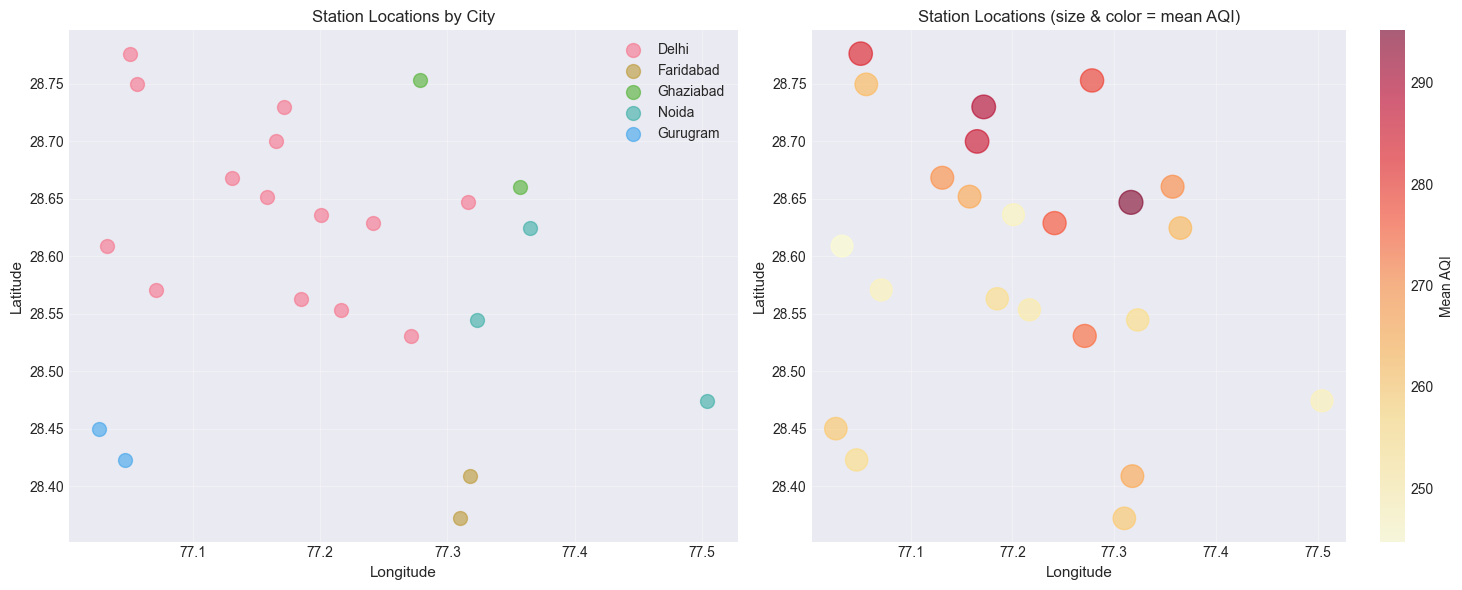

✓ Spatial coverage visualized


In [14]:
# Visualize station locations
station_info = df.groupby('station').agg({
    'latitude': 'first',
    'longitude': 'first',
    'city': 'first',
    'aqi': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Station locations by city
for city in station_info['city'].unique():
    city_data = station_info[station_info['city'] == city]
    ax1.scatter(city_data['longitude'], city_data['latitude'],
                label=city, s=100, alpha=0.6)
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title('Station Locations by City', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Station locations sized by mean AQI
scatter = ax2.scatter(station_info['longitude'], station_info['latitude'],
                     c=station_info['aqi'], s=station_info['aqi'],
                     alpha=0.6, cmap='YlOrRd')
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.set_title('Station Locations (size & color = mean AQI)', fontsize=12)
plt.colorbar(scatter, ax=ax2, label='Mean AQI')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Spatial coverage visualized")

## 6. Target Variable: AQI Distribution

In [38]:
# AQI summary statistics
print("AQI Summary Statistics:")
print(df['aqi'].describe())

print(f"\nKey Statistics:")
print(f"  Mean: {df['aqi'].mean():.1f}")
print(f"  Median: {df['aqi'].median():.1f}")
print(f"  Std Dev: {df['aqi'].std():.1f}")
print(f"  Range: {df['aqi'].min():.0f} - {df['aqi'].max():.0f}")

AQI Summary Statistics:
count    201664.00
mean        265.83
std         171.51
min          25.00
25%         103.00
50%         232.00
75%         464.00
max         500.00
Name: aqi, dtype: float64

Key Statistics:
  Mean: 265.8
  Median: 232.0
  Std Dev: 171.5
  Range: 25 - 500


In [16]:
# AQI category distribution
print("AQI Category Distribution:")
category_counts = df['aqi_category'].value_counts()
print(category_counts)

print(f"\nCategory Percentages:")
print((category_counts / len(df) * 100).round(2))

print(f"\n⚠️ Key Insight: {(category_counts['Severe']/len(df)*100):.1f}% of observations are in 'Severe' category!")

AQI Category Distribution:
aqi_category
Severe          60102
Moderate        45397
Satisfactory    32860
Very Poor       29674
Poor            18843
Good            14788
Name: count, dtype: int64

Category Percentages:
aqi_category
Severe          29.80
Moderate        22.51
Satisfactory    16.29
Very Poor       14.71
Poor             9.34
Good             7.33
Name: count, dtype: float64

⚠️ Key Insight: 29.8% of observations are in 'Severe' category!


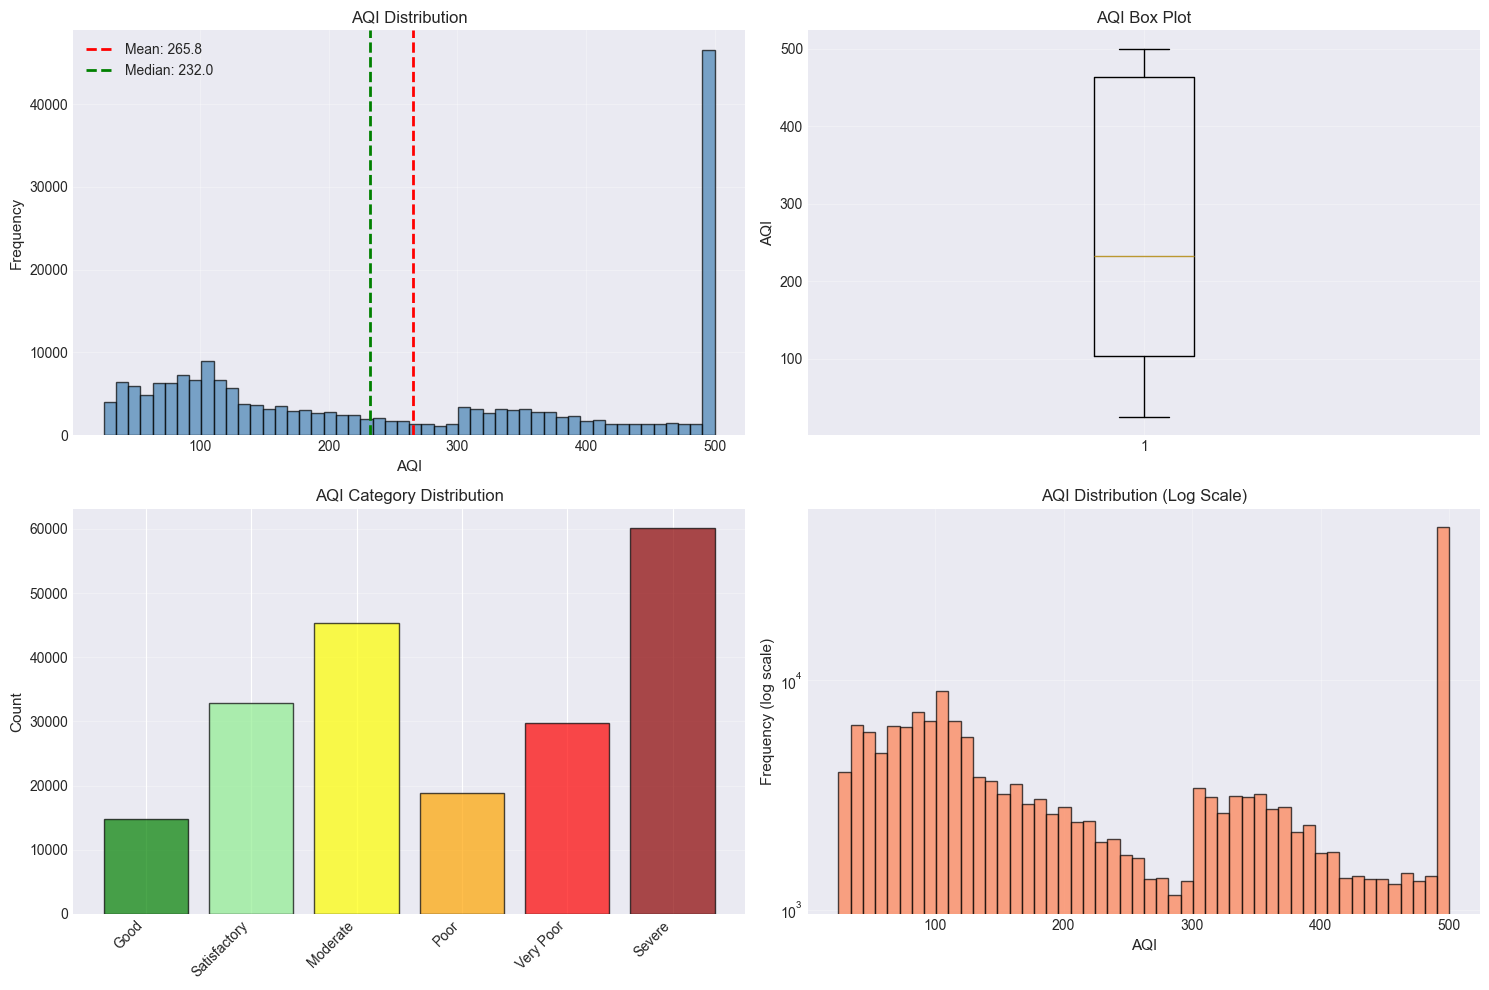

In [17]:
# Visualize AQI distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('AQI', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('AQI Distribution', fontsize=12)
axes[0, 0].axvline(df['aqi'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["aqi"].mean():.1f}', linewidth=2)
axes[0, 0].axvline(df['aqi'].median(), color='green', linestyle='--', 
                   label=f'Median: {df["aqi"].median():.1f}', linewidth=2)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df['aqi'].dropna(), vert=True)
axes[0, 1].set_ylabel('AQI', fontsize=11)
axes[0, 1].set_title('AQI Box Plot', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Category bar plot
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_counts = df['aqi_category'].value_counts().reindex(category_order, fill_value=0)
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
axes[1, 0].bar(range(len(cat_counts)), cat_counts.values, color=colors, 
               alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(cat_counts)))
axes[1, 0].set_xticklabels(cat_counts.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title('AQI Category Distribution', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Log-scale histogram
axes[1, 1].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('AQI', fontsize=11)
axes[1, 1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[1, 1].set_title('AQI Distribution (Log Scale)', fontsize=12)
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Pollutant Analysis

In [18]:
# Pollutant summary statistics
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
pollutant_stats = df[pollutants].describe().T

print("Pollutant Summary Statistics:")
print(pollutant_stats)

print("\n📊 Key Observations:")
print(f"  • PM2.5: mean={df['pm25'].mean():.1f}, max={df['pm25'].max():.1f} (highly variable)")
print(f"  • PM10: mean={df['pm10'].mean():.1f}, max={df['pm10'].max():.1f} (very high)")
print(f"  • O3: relatively stable (mean={df['o3'].mean():.1f}, std={df['o3'].std():.1f})")

Pollutant Summary Statistics:
         count    mean     std   min     25%     50%     75%      max
pm25  201664.0  183.42  193.14  15.0   55.30   99.50  254.70   900.00
pm10  201664.0  348.57  370.02  24.0  104.10  189.80  481.20  1979.70
no2   201664.0   69.76   75.97   8.0   19.90   38.30   94.00   593.50
so2   201664.0   16.03   17.20   4.0    4.50    8.70   20.90   121.60
co    201664.0    3.03    3.28   0.3    0.87    1.69    4.12    22.67
o3    201664.0   27.19   13.57  12.0   18.00   23.30   31.80    84.00

📊 Key Observations:
  • PM2.5: mean=183.4, max=900.0 (highly variable)
  • PM10: mean=348.6, max=1979.7 (very high)
  • O3: relatively stable (mean=27.2, std=13.6)


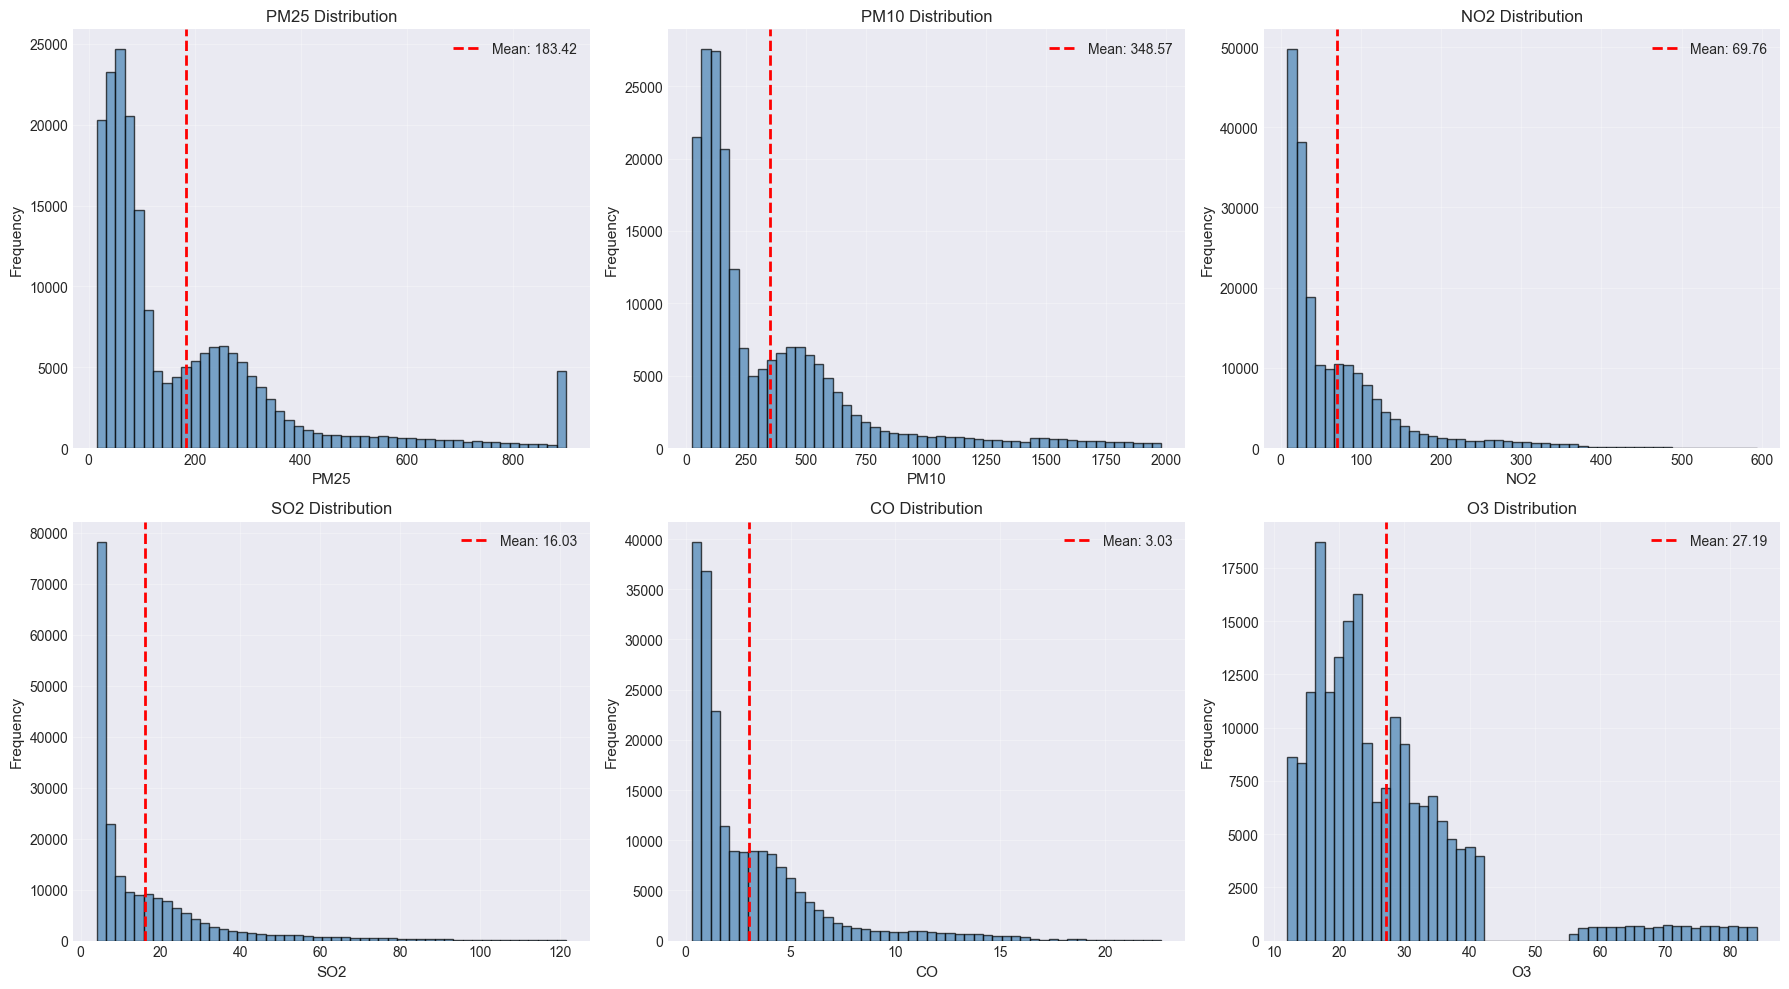

In [19]:
# Visualize pollutant distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pollutant in enumerate(pollutants):
    axes[i].hist(df[pollutant].dropna(), bins=50, edgecolor='black', 
                 alpha=0.7, color='steelblue')
    axes[i].set_xlabel(pollutant.upper(), fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].set_title(f'{pollutant.upper()} Distribution', fontsize=12)
    axes[i].axvline(df[pollutant].mean(), color='red', linestyle='--',
                    label=f'Mean: {df[pollutant].mean():.2f}', linewidth=2)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Weather Variables Analysis

In [20]:
# Weather summary statistics
weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']
weather_stats = df[weather_vars].describe().T

print("Weather Variable Summary Statistics:")
print(weather_stats)

print("\n🌡️ Key Observations:")
print(f"  • Temperature: {df['temperature'].min():.1f}°C to {df['temperature'].max():.1f}°C")
print(f"  • Humidity: {df['humidity'].min():.0f}% to {df['humidity'].max():.0f}%")
print(f"  • Visibility: mean={df['visibility'].mean():.1f}km (low visibility frequent)")

Weather Variable Summary Statistics:
                count   mean    std   min   25%   50%   75%    max
temperature  201664.0  26.90   8.98   6.0  19.9  27.6  33.5   44.8
humidity     201664.0  61.04  24.74  20.0  39.0  58.0  83.0  100.0
wind_speed   201664.0  10.53   6.05   2.1   5.9   9.2  14.2   31.5
visibility   201664.0   5.01   3.69   0.2   1.9   4.4   7.1   15.0

🌡️ Key Observations:
  • Temperature: 6.0°C to 44.8°C
  • Humidity: 20% to 100%
  • Visibility: mean=5.0km (low visibility frequent)


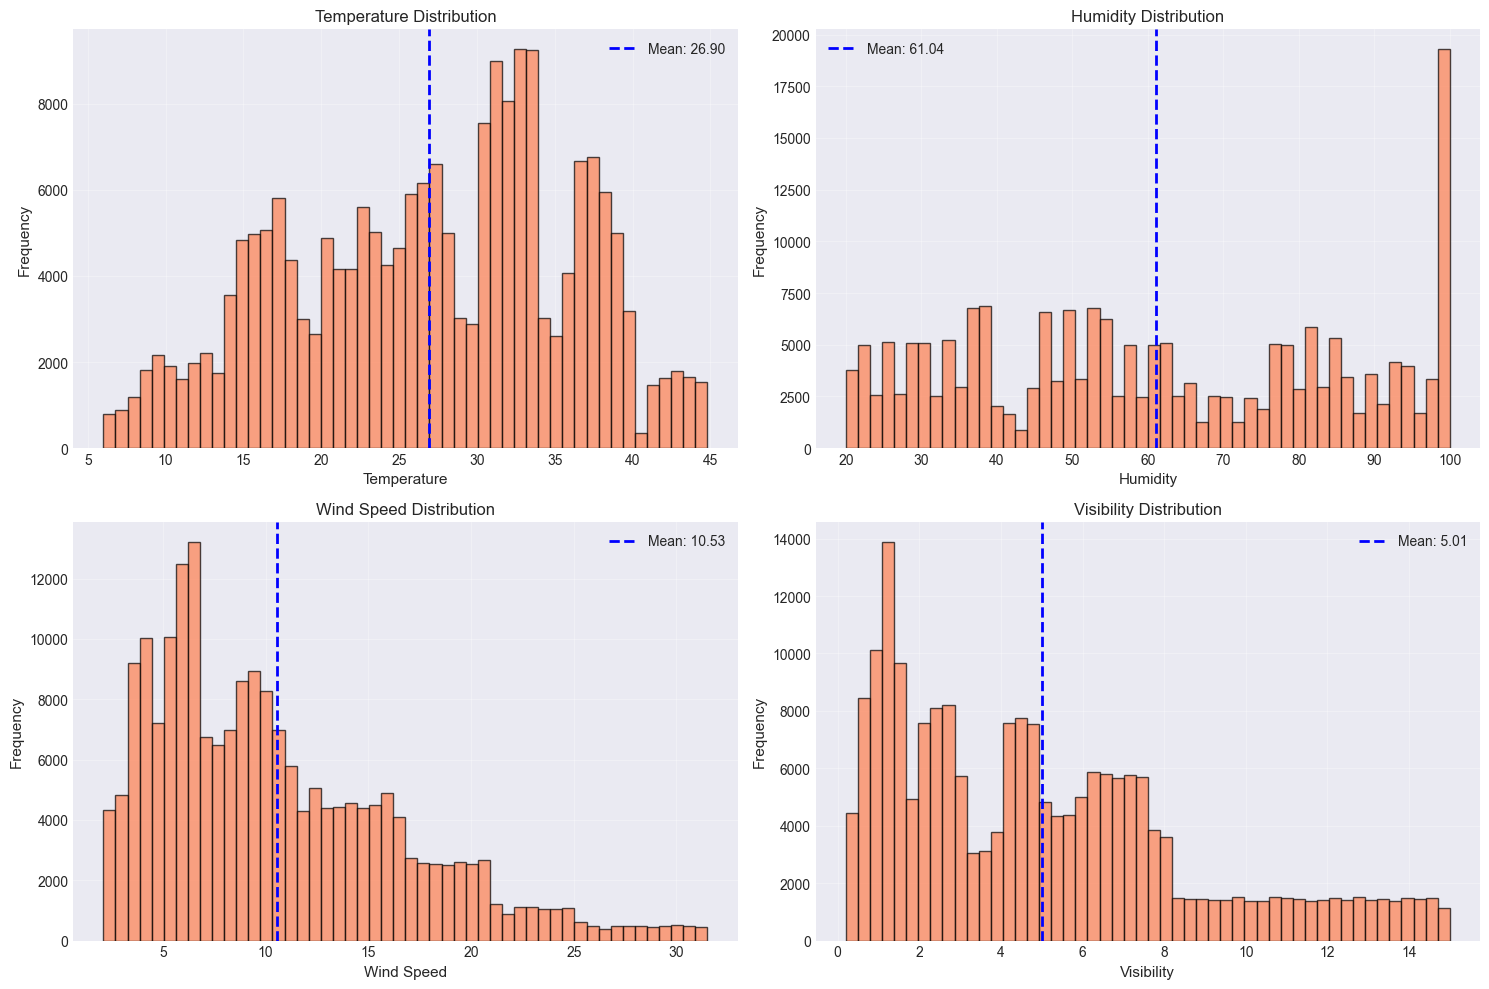

In [21]:
# Visualize weather distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(weather_vars):
    axes[i].hist(df[var].dropna(), bins=50, edgecolor='black', 
                 alpha=0.7, color='coral')
    axes[i].set_xlabel(var.replace('_', ' ').title(), fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].set_title(f'{var.replace("_", " ").title()} Distribution', fontsize=12)
    axes[i].axvline(df[var].mean(), color='blue', linestyle='--',
                    label=f'Mean: {df[var].mean():.2f}', linewidth=2)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

In [22]:
# Correlation with AQI
feature_cols = pollutants + weather_vars
correlations = df[feature_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)

print("Correlation with AQI:")
print(correlations)

print("\n🔍 Key Insights:")
print(f"  • Strongest positive: {correlations.idxmax()} ({correlations.max():.3f})")
print(f"  • Strongest negative: {correlations.idxmin()} ({correlations.min():.3f})")
print(f"  • Visibility has VERY strong negative correlation - critical feature!")

Correlation with AQI:
pm25           0.80
pm10           0.80
co             0.78
no2            0.77
so2            0.76
humidity      -0.22
o3            -0.28
wind_speed    -0.54
temperature   -0.73
visibility    -0.86
Name: aqi, dtype: float64

🔍 Key Insights:
  • Strongest positive: pm25 (0.801)
  • Strongest negative: visibility (-0.857)
  • Visibility has VERY strong negative correlation - critical feature!


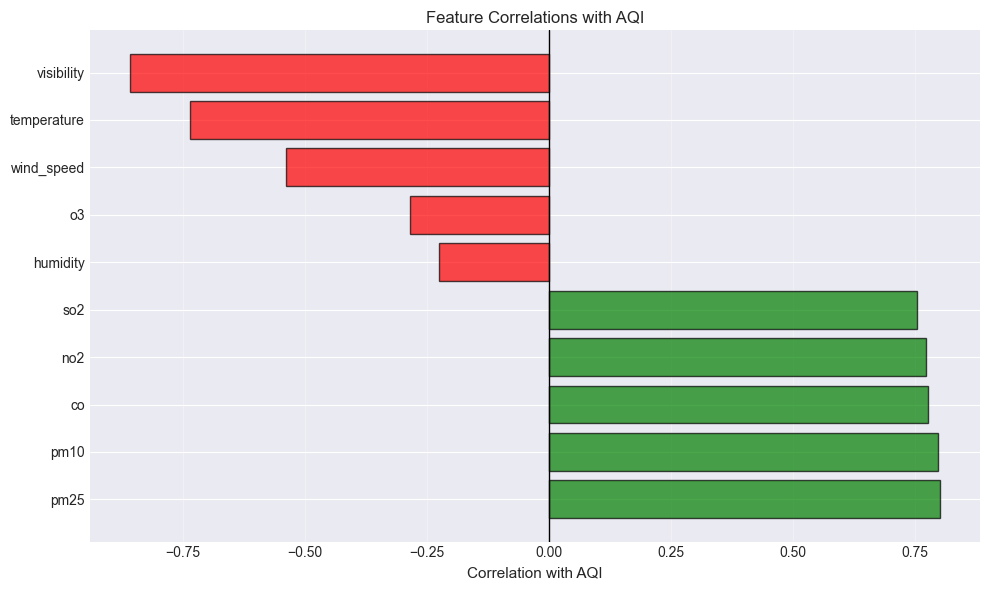

In [23]:
# Visualize correlations with AQI
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
bars = ax.barh(range(len(correlations)), correlations.values, 
               color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index)
ax.set_xlabel('Correlation with AQI', fontsize=11)
ax.set_title('Feature Correlations with AQI', fontsize=12)
ax.axvline(0, color='black', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

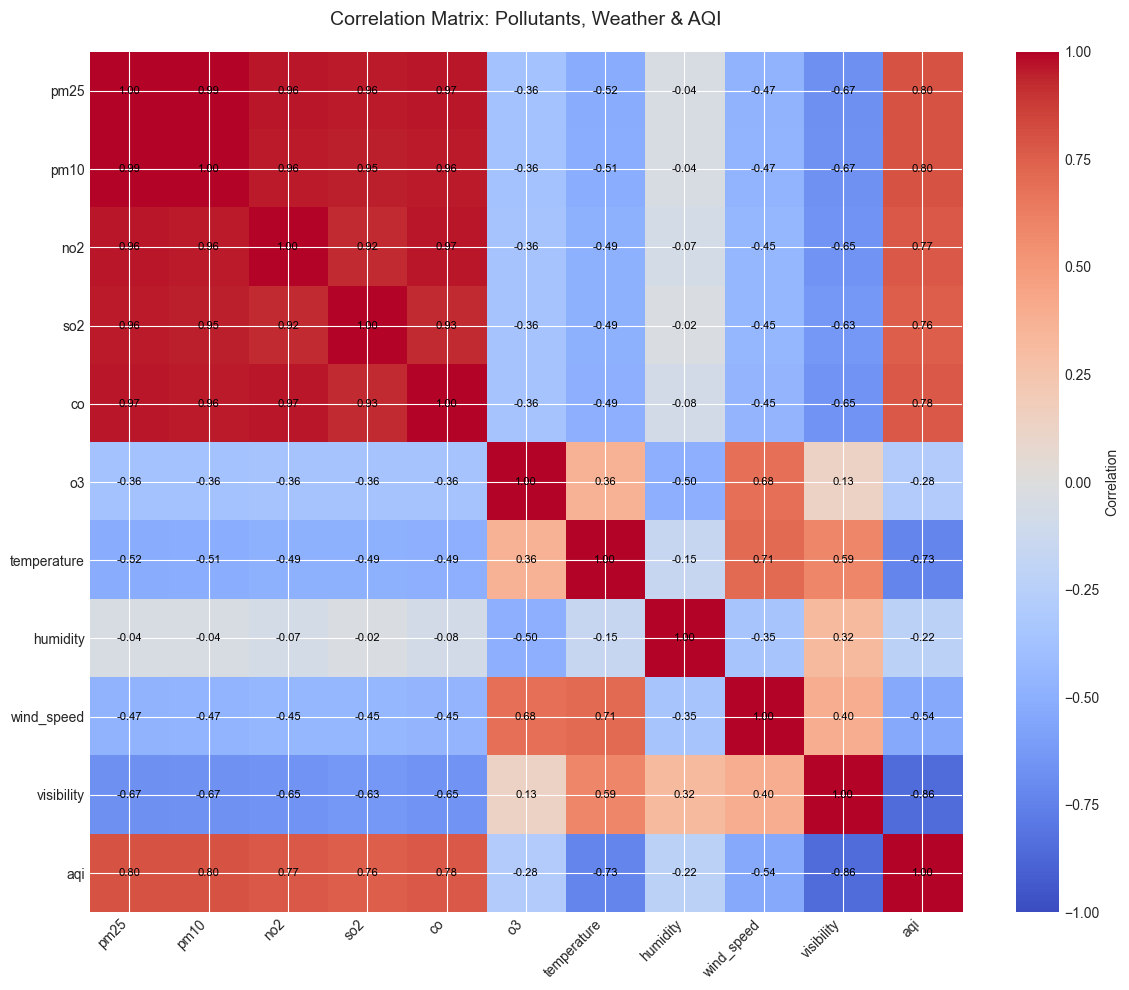

In [24]:
# Full correlation matrix heatmap
corr_matrix = df[feature_cols + ['aqi']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
ax.set_title('Correlation Matrix: Pollutants, Weather & AQI', fontsize=14, pad=20)

# Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

## 10. Temporal Patterns

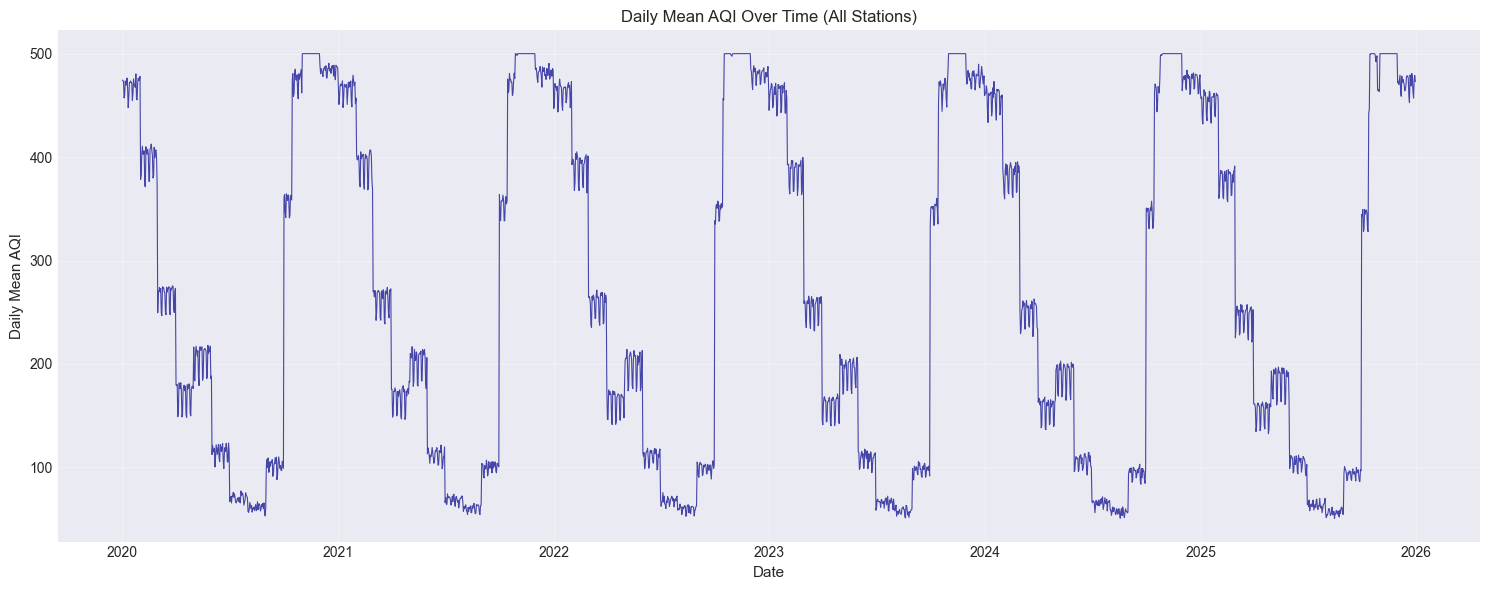

✓ Clear seasonal patterns visible (winter peaks)


In [25]:
# AQI over time (daily mean)
daily_aqi = df.set_index('datetime')['aqi'].resample('D').mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_aqi.index, daily_aqi.values, alpha=0.7, linewidth=0.8, color='darkblue')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily Mean AQI', fontsize=11)
ax.set_title('Daily Mean AQI Over Time (All Stations)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Clear seasonal patterns visible (winter peaks)")

AQI Statistics by Hour of Day:
        mean     std  median
hour                        
6     271.31  178.68   229.0
12    243.36  166.85   168.0
18    281.62  163.12   292.0
23    267.04  174.65   230.0


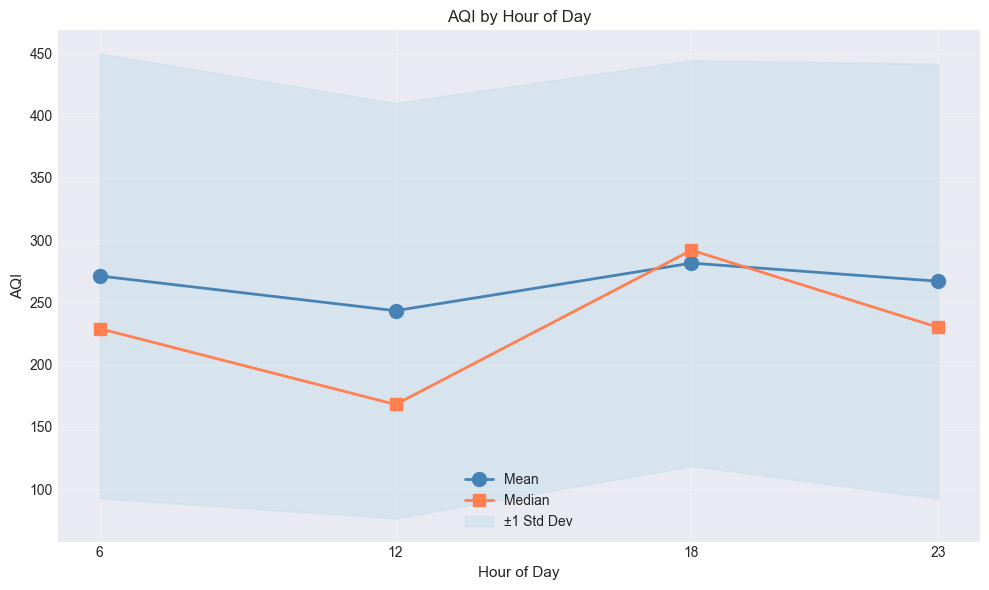


⏰ Key Insight: Hour 18 has highest AQI, Hour 12 has lowest


In [26]:
# AQI by hour of day
hourly_stats = df.groupby('hour')['aqi'].agg(['mean', 'std', 'median'])

print("AQI Statistics by Hour of Day:")
print(hourly_stats)

fig, ax = plt.subplots(figsize=(10, 6))
hours = hourly_stats.index
ax.plot(hours, hourly_stats['mean'], marker='o', label='Mean', 
        linewidth=2, markersize=10, color='steelblue')
ax.plot(hours, hourly_stats['median'], marker='s', label='Median', 
        linewidth=2, markersize=8, color='coral')
ax.fill_between(hours,
                hourly_stats['mean'] - hourly_stats['std'],
                hourly_stats['mean'] + hourly_stats['std'],
                alpha=0.3, label='±1 Std Dev', color='lightblue')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('AQI', fontsize=11)
ax.set_title('AQI by Hour of Day', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)

plt.tight_layout()
plt.show()

print(f"\n⏰ Key Insight: Hour {hourly_stats['mean'].idxmax()} has highest AQI, "
      f"Hour {hourly_stats['mean'].idxmin()} has lowest")

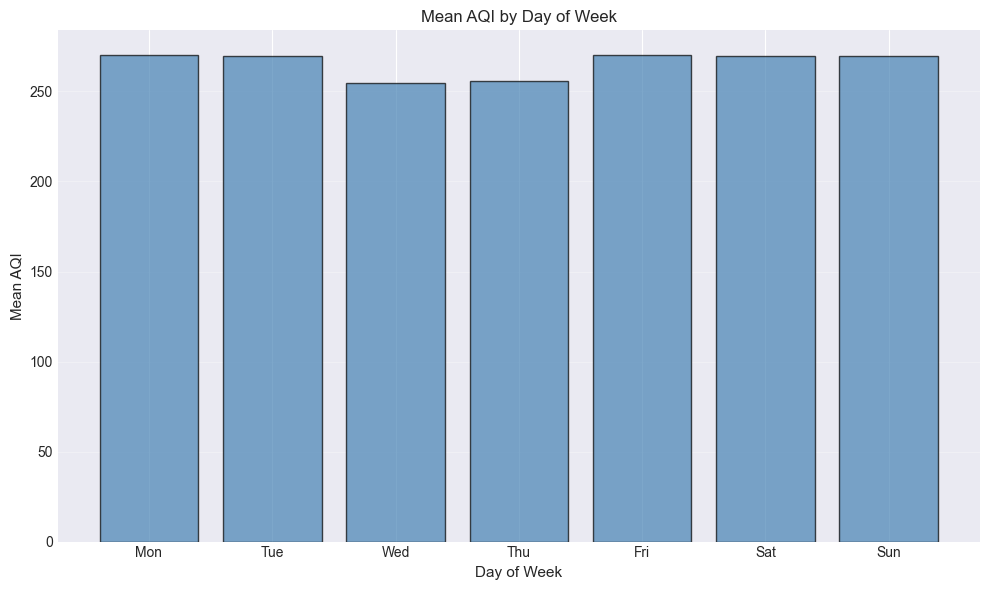

📅 Relatively flat across days - weak weekend effect


In [27]:
# AQI by day of week
dow_stats = df.groupby('day_of_week')['aqi'].agg(['mean', 'median'])
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(7), dow_stats['mean'].values, alpha=0.7, 
       color='steelblue', edgecolor='black')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
ax.set_title('Mean AQI by Day of Week', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📅 Relatively flat across days - weak weekend effect")

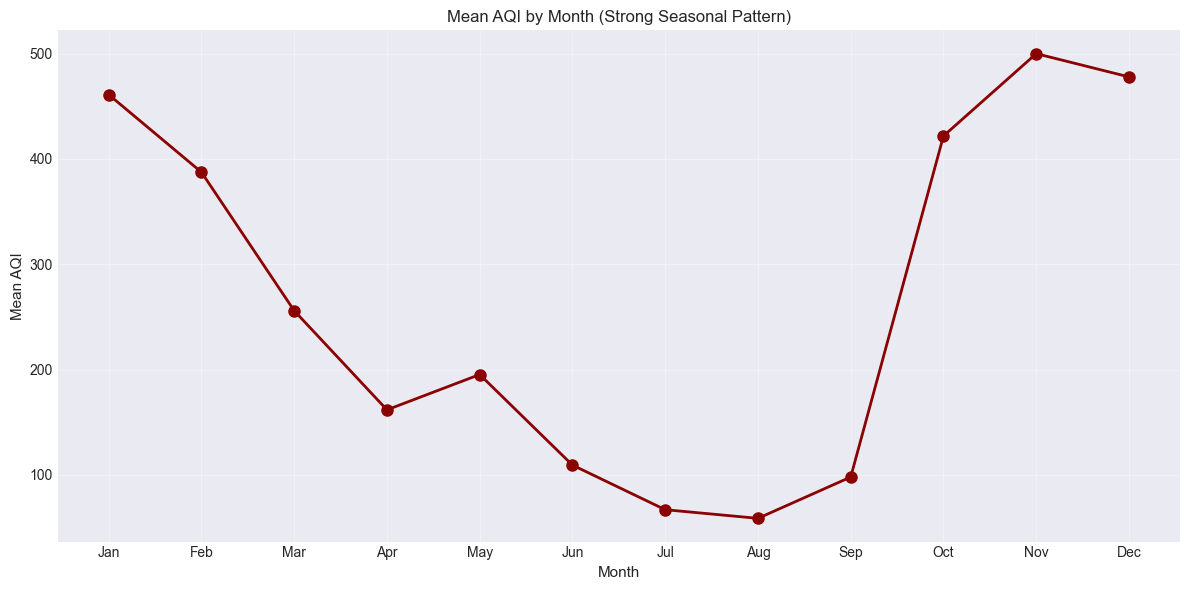


🌨️ Key Insight: Winter months (Nov-Jan) have MUCH higher AQI


In [28]:
# AQI by month
monthly_stats = df.groupby('month')['aqi'].agg(['mean', 'median'])
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, 13), monthly_stats['mean'].values, marker='o', 
        linewidth=2, markersize=8, color='darkred')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
ax.set_title('Mean AQI by Month (Strong Seasonal Pattern)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🌨️ Key Insight: Winter months (Nov-Jan) have MUCH higher AQI")

AQI Statistics by Season:
                mean  median    std    count
season                                      
winter        457.79   500.0  59.26  66424.0
summer        204.79   198.0  64.94  50784.0
monsoon        82.89    82.0  34.76  67344.0
post-monsoon     NaN     NaN    NaN      NaN


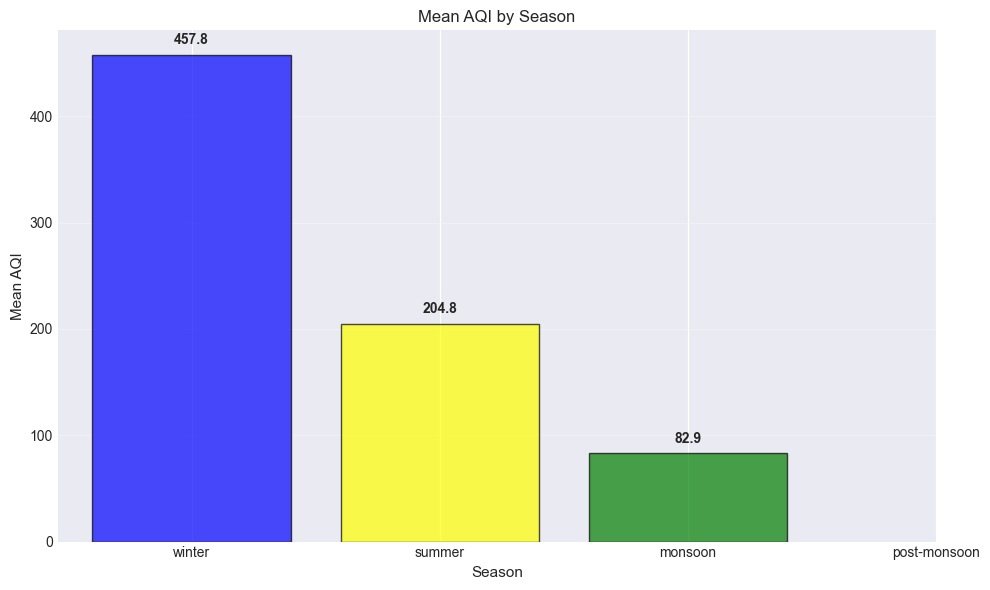


❄️ CRITICAL: Winter AQI (457.8) is 5.5× higher than monsoon!


In [29]:
# AQI by season
season_stats = df.groupby('season')['aqi'].agg(['mean', 'median', 'std', 'count'])
season_order = ['winter', 'summer', 'monsoon', 'post-monsoon']
season_stats = season_stats.reindex(season_order)

print("AQI Statistics by Season:")
print(season_stats)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'yellow', 'green', 'orange']
bars = ax.bar(range(len(season_stats)), season_stats['mean'].values,
              alpha=0.7, color=colors, edgecolor='black')
ax.set_xticks(range(len(season_stats)))
ax.set_xticklabels(season_stats.index, rotation=0)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
ax.set_title('Mean AQI by Season', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(season_stats['mean'].values):
    ax.text(i, v + 10, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

winter_mean = season_stats.loc['winter', 'mean']
monsoon_mean = season_stats.loc['monsoon', 'mean']
print(f"\n❄️ CRITICAL: Winter AQI ({winter_mean:.1f}) is {winter_mean/monsoon_mean:.1f}× higher than monsoon!")

## 11. Spatial Patterns

AQI Statistics by City:
             mean  median     std
city                             
Ghaziabad  275.08   250.0  171.84
Delhi      268.10   238.0  171.52
Faridabad  263.27   225.5  171.45
Gurugram   258.22   214.0  171.23
Noida      255.87   209.0  170.83


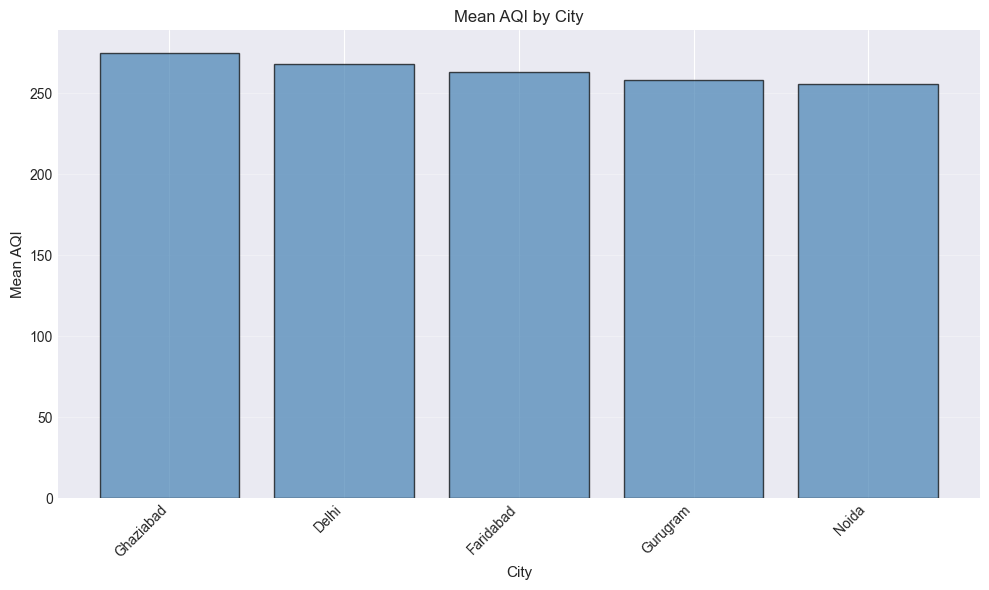

In [30]:
# AQI by city
city_stats = df.groupby('city')['aqi'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

print("AQI Statistics by City:")
print(city_stats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(city_stats)), city_stats['mean'].values, 
       alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xticks(range(len(city_stats)))
ax.set_xticklabels(city_stats.index, rotation=45, ha='right')
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
ax.set_title('Mean AQI by City', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Top 20 Stations by Mean AQI:
                        mean  median     std  count
station                                            
Anand Vihar, Delhi    295.17   298.0  170.34   8768
Jahangirpuri, Delhi   289.72   287.0  170.84   8768
Wazirpur, Delhi       286.59   277.0  171.10   8768
Bawana, Delhi         283.69   270.0  171.39   8768
Ghaziabad Loni        279.57   262.0  171.43   8768
ITO, Delhi            276.97   252.0  171.45   8768
Okhla Phase 2, Delhi  274.13   250.0  172.02   8768
Ghaziabad Vasundhara  270.59   240.0  172.14   8768
Punjabi Bagh, Delhi   270.28   239.0  171.19   8768
Shadipur, Delhi       266.13   230.0  171.63   8768
Faridabad Sec 16A     266.11   232.0  171.41   8768
Noida Sec 62          263.22   225.0  171.28   8768
Rohini, Delhi         263.04   225.0  171.58   8768
Gurugram Vikas Sadan  260.43   217.0  171.54   8768
Faridabad New Town    260.43   218.0  171.44   8768
Gurugram Sec 51       256.01   211.0  170.90   8768
Noida Sec 125         255.90   210.

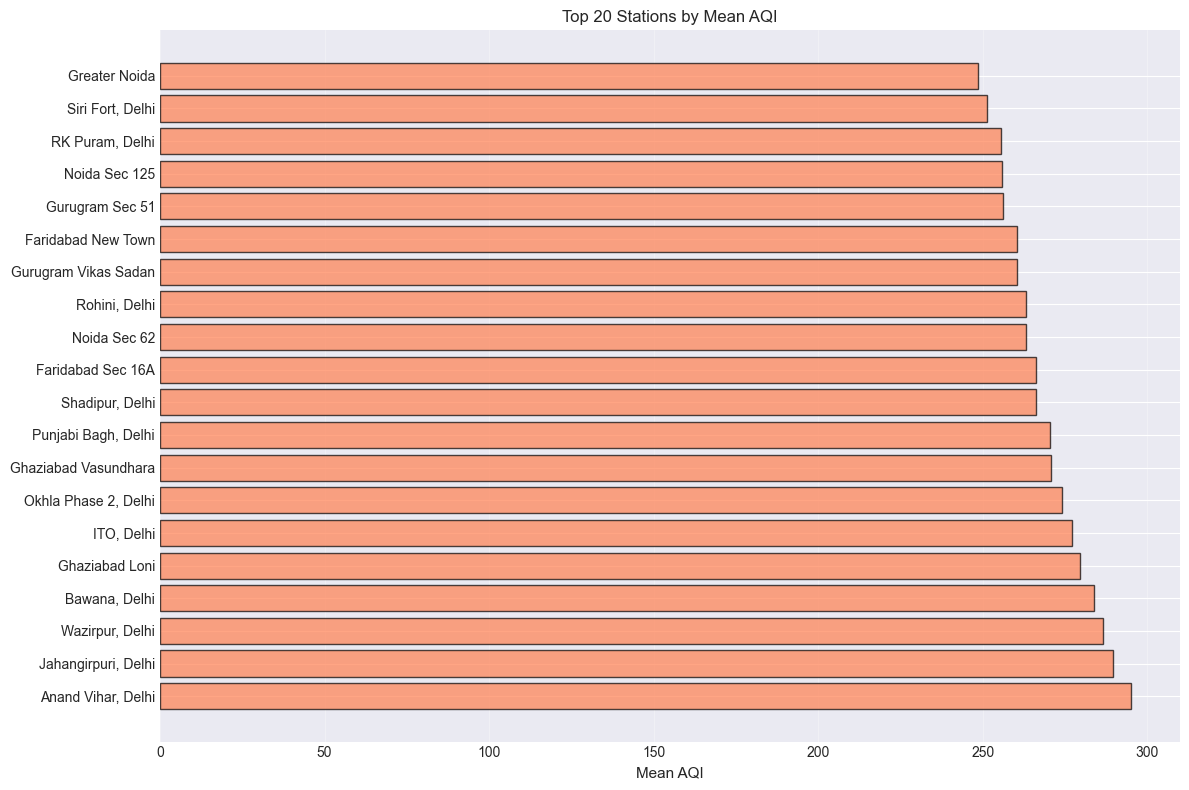


🏭 Highest pollution: Anand Vihar, Delhi (mean AQI: 295.2)


In [31]:
# Top 20 stations by mean AQI
station_stats = df.groupby('station')['aqi'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
top_20_stations = station_stats.head(20)

print("Top 20 Stations by Mean AQI:")
print(top_20_stations)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_20_stations)), top_20_stations['mean'].values, 
        alpha=0.7, edgecolor='black', color='coral')
ax.set_yticks(range(len(top_20_stations)))
ax.set_yticklabels(top_20_stations.index)
ax.set_xlabel('Mean AQI', fontsize=11)
ax.set_title('Top 20 Stations by Mean AQI', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n🏭 Highest pollution: {top_20_stations.index[0]} (mean AQI: {top_20_stations['mean'].iloc[0]:.1f})")

## 12. AQI Persistence Analysis

**Critical for forecasting:** Check how much AQI changes from one measurement to the next (6 hours ahead)

In [32]:
# Create target variable (next measurement AQI)
df_sorted = df.sort_values(['station', 'datetime']).copy()
df_sorted['aqi_next'] = df_sorted.groupby('station')['aqi'].shift(-1)

# Remove rows where we can't compute next AQI
df_persist = df_sorted.dropna(subset=['aqi_next']).copy()

print(f"Rows with both current and next AQI: {len(df_persist):,}")
print(f"Rows dropped (last measurement per station): {len(df_sorted) - len(df_persist):,}")

Rows with both current and next AQI: 201,641
Rows dropped (last measurement per station): 23


In [33]:
# Calculate AQI change
df_persist['aqi_change'] = df_persist['aqi_next'] - df_persist['aqi']
df_persist['aqi_pct_change'] = (df_persist['aqi_change'] / df_persist['aqi'] * 100)

print("AQI Change Statistics (t to t+1):")
print(df_persist['aqi_change'].describe())

print("\nAQI % Change Statistics:")
print(df_persist['aqi_pct_change'].describe())

print(f"\n📊 Key Statistics:")
print(f"  • Mean change: {df_persist['aqi_change'].mean():.2f} AQI points")
print(f"  • Median change: {df_persist['aqi_change'].median():.2f} AQI points")
print(f"  • Std dev: {df_persist['aqi_change'].std():.2f} AQI points")
print(f"  • Max increase: {df_persist['aqi_change'].max():.0f} AQI points")
print(f"  • Max decrease: {df_persist['aqi_change'].min():.0f} AQI points")

AQI Change Statistics (t to t+1):
count    2.02e+05
mean    -5.80e-04
std      5.58e+01
min     -2.97e+02
25%     -2.90e+01
50%      0.00e+00
75%      2.50e+01
max      3.43e+02
Name: aqi_change, dtype: float64

AQI % Change Statistics:
count    201641.00
mean          6.65
std          41.83
min         -81.73
25%         -15.88
50%           0.00
75%          15.58
max         794.74
Name: aqi_pct_change, dtype: float64

📊 Key Statistics:
  • Mean change: -0.00 AQI points
  • Median change: 0.00 AQI points
  • Std dev: 55.84 AQI points
  • Max increase: 343 AQI points
  • Max decrease: -297 AQI points


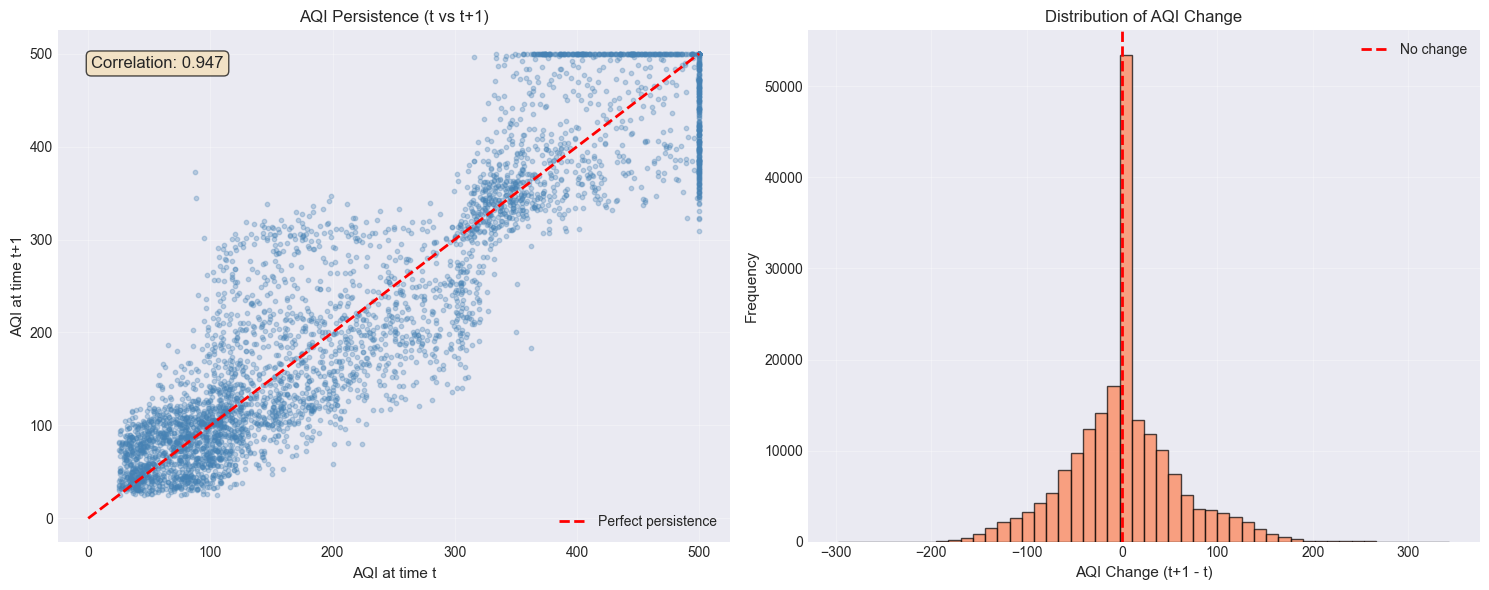


🔑 KEY INSIGHT: AQI correlation (t vs t+1) = 0.947
   → This suggests persistence is a VERY STRONG baseline
   → ML models must beat this high bar!


In [34]:
# Scatter plot: current AQI vs next AQI
sample = df_persist.sample(min(5000, len(df_persist)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
axes[0].scatter(sample['aqi'], sample['aqi_next'], alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 500], [0, 500], 'r--', label='Perfect persistence', linewidth=2)
axes[0].set_xlabel('AQI at time t', fontsize=11)
axes[0].set_ylabel('AQI at time t+1', fontsize=11)
axes[0].set_title('AQI Persistence (t vs t+1)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calculate correlation
corr = df_persist['aqi'].corr(df_persist['aqi_next'])
axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}',
            transform=axes[0].transAxes, fontsize=12,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Distribution of AQI change
axes[1].hist(df_persist['aqi_change'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[1].set_xlabel('AQI Change (t+1 - t)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of AQI Change', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🔑 KEY INSIGHT: AQI correlation (t vs t+1) = {corr:.3f}")
if corr > 0.9:
    print(f"   → This suggests persistence is a VERY STRONG baseline")
    print(f"   → ML models must beat this high bar!")
elif corr > 0.8:
    print(f"   → This suggests persistence is a STRONG baseline")
else:
    print(f"   → This suggests moderate persistence")

AQI Change by Hour Transition:
                  mean    std  median  count
hour_transition                             
12 → 18.0        38.26  56.31    26.0  50416
18 → 23.0       -14.60  46.02    -6.0  50393
18 → nan         11.00  44.40     0.0     23
23 → 6.0          4.27  43.92     0.0  50393
6 → 12.0        -27.95  52.71   -14.0  50416


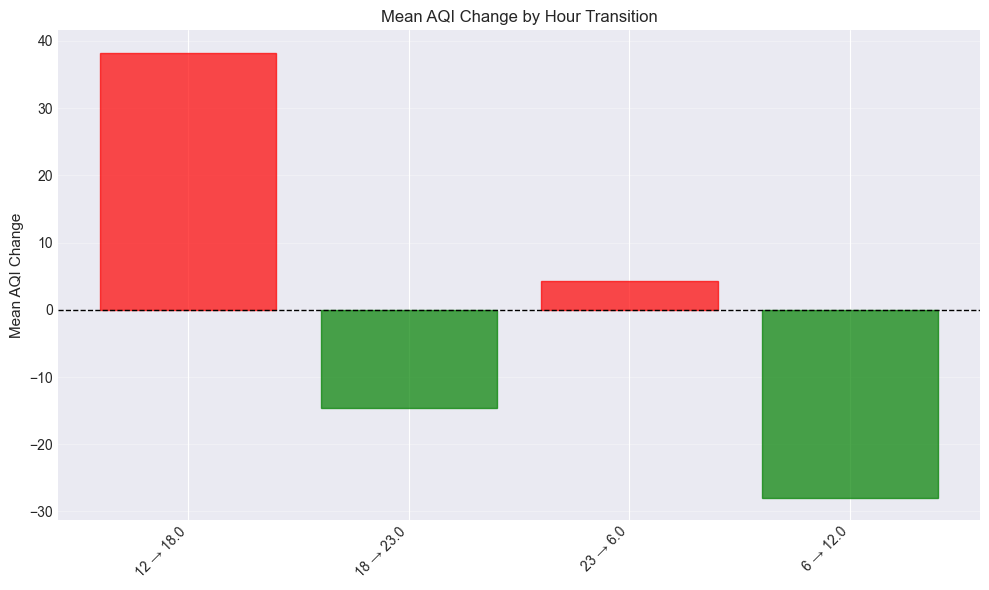


⏰ Key Insight: Different hour transitions have different typical changes
   → This suggests time-of-day adjusted persistence could beat simple persistence!


In [35]:
# AQI change by hour transition
df_persist['next_hour'] = df_persist.groupby('station')['hour'].shift(-1)
df_persist['hour_transition'] = df_persist['hour'].astype(str) + ' → ' + df_persist['next_hour'].astype(str)

transition_stats = df_persist.groupby('hour_transition')['aqi_change'].agg(['mean', 'std', 'median', 'count'])

print("AQI Change by Hour Transition:")
print(transition_stats)

# Plot
valid_transitions = transition_stats[transition_stats['count'] > 100].sort_index()
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = range(len(valid_transitions))
bars = ax.bar(x_pos, valid_transitions['mean'].values, alpha=0.7, edgecolor='black')

# Color bars based on change direction
for i, bar in enumerate(bars):
    if valid_transitions['mean'].iloc[i] > 0:
        bar.set_color('red')
    else:
        bar.set_color('green')

ax.set_xticks(x_pos)
ax.set_xticklabels(valid_transitions.index, rotation=45, ha='right')
ax.set_ylabel('Mean AQI Change', fontsize=11)
ax.set_title('Mean AQI Change by Hour Transition', fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n⏰ Key Insight: Different hour transitions have different typical changes")
print("   → This suggests time-of-day adjusted persistence could beat simple persistence!")

## 13. Summary of Key Findings

In [36]:
print("="*70)
print("COMPREHENSIVE EDA SUMMARY")
print("="*70)

print("\n1. DATA CHARACTERISTICS:")
print(f"   • {len(df):,} observations from {df['station'].nunique()} stations across {df['city'].nunique()} cities")
print(f"   • Time period: {df['datetime'].min().date()} to {df['datetime'].max().date()}")
print(f"   • Only 4 measurements per day (hours: 6, 12, 18, 23)")
print(f"   • ✓ No missing values!")
print(f"   • Prediction task: 6-hour ahead (not 1 hour!)")

print("\n2. TARGET VARIABLE (AQI):")
print(f"   • Mean: {df['aqi'].mean():.1f}, Median: {df['aqi'].median():.1f}")
print(f"   • Range: {df['aqi'].min():.0f} to {df['aqi'].max():.0f} (capped at 500)")
print(f"   • Distribution: Right-skewed, {(df['aqi_category']=='Severe').sum()/len(df)*100:.1f}% in 'Severe' category")
print(f"   • High persistence: correlation(t, t+1) = {corr:.3f}")

print("\n3. STRONGEST PREDICTIVE FEATURES:")
print("   Positive correlations:")
for feat in correlations.head(3).index:
    print(f"     • {feat}: {correlations[feat]:.3f}")
print("   Negative correlations:")
for feat in correlations.tail(3).index:
    print(f"     • {feat}: {correlations[feat]:.3f}")
print(f"   → Visibility is the STRONGEST predictor ({correlations['visibility']:.3f})!")

print("\n4. TEMPORAL PATTERNS:")
print(f"   • Hour of day: Hour {hourly_stats['mean'].idxmax()} highest, Hour {hourly_stats['mean'].idxmin()} lowest")
print(f"   • Season: Winter AQI ({season_stats.loc['winter','mean']:.1f}) is {season_stats.loc['winter','mean']/season_stats.loc['monsoon','mean']:.1f}× monsoon")
print(f"   • Month: Nov-Jan have highest AQI (winter pollution)")
print(f"   • Day of week: Relatively flat (weak weekend effect)")

print("\n5. SPATIAL PATTERNS:")
print(f"   • City variation: {city_stats.index[0]} highest (mean={city_stats['mean'].iloc[0]:.1f})")
print(f"   • Station variation: {station_stats.index[0]} highest (mean={station_stats['mean'].iloc[0]:.1f})")
print(f"   • Clear geographic clustering visible")

print("\n6. IMPLICATIONS FOR MODELING:")
print(f"   ✓ Persistence baseline will perform well (corr={corr:.2f})")
print(f"   ✓ Lag features are CRITICAL (previous 1-2 measurements)")
print(f"   ✓ Visibility is single most important weather feature")
print(f"   ✓ Temporal features (hour, season, month) are important")
print(f"   ✓ Time-of-day effects should be modeled (asymmetric transitions)")
print(f"   ✓ Station/city effects exist - consider in advanced models")
print(f"   ✓ High autocorrelation ideal for LSTM/GRU architectures")

print("\n" + "="*70)
print("EDA COMPLETE ✓")
print("="*70)

COMPREHENSIVE EDA SUMMARY

1. DATA CHARACTERISTICS:
   • 201,664 observations from 23 stations across 5 cities
   • Time period: 2020-01-01 to 2025-12-31
   • Only 4 measurements per day (hours: 6, 12, 18, 23)
   • ✓ No missing values!
   • Prediction task: 6-hour ahead (not 1 hour!)

2. TARGET VARIABLE (AQI):
   • Mean: 265.8, Median: 232.0
   • Range: 25 to 500 (capped at 500)
   • Distribution: Right-skewed, 29.8% in 'Severe' category
   • High persistence: correlation(t, t+1) = 0.947

3. STRONGEST PREDICTIVE FEATURES:
   Positive correlations:
     • pm25: 0.801
     • pm10: 0.798
     • co: 0.777
   Negative correlations:
     • wind_speed: -0.537
     • temperature: -0.734
     • visibility: -0.857
   → Visibility is the STRONGEST predictor (-0.857)!

4. TEMPORAL PATTERNS:
   • Hour of day: Hour 18 highest, Hour 12 lowest
   • Season: Winter AQI (457.8) is 5.5× monsoon
   • Month: Nov-Jan have highest AQI (winter pollution)
   • Day of week: Relatively flat (weak weekend effect)


## 14. Export for Further Analysis

In [37]:
# Save processed dataframe with persistence features
df_persist.to_csv('delhi_aqi_with_persistence.csv', index=False)
print("✓ Processed data saved to 'delhi_aqi_with_persistence.csv'")

# Save summary statistics
summary_stats = {
    'n_observations': len(df),
    'n_stations': df['station'].nunique(),
    'n_cities': df['city'].nunique(),
    'date_range': f"{df['datetime'].min().date()} to {df['datetime'].max().date()}",
    'aqi_mean': df['aqi'].mean(),
    'aqi_median': df['aqi'].median(),
    'aqi_std': df['aqi'].std(),
    'persistence_correlation': corr,
    'top_feature': correlations.index[0],
    'top_correlation': correlations.iloc[0]
}

print("\n📊 Summary statistics for reference:")
for key, value in summary_stats.items():
    print(f"   {key}: {value}")

✓ Processed data saved to 'delhi_aqi_with_persistence.csv'

📊 Summary statistics for reference:
   n_observations: 201664
   n_stations: 23
   n_cities: 5
   date_range: 2020-01-01 to 2025-12-31
   aqi_mean: 265.83014816724847
   aqi_median: 232.0
   aqi_std: 171.50895034698647
   persistence_correlation: 0.9469940717252503
   top_feature: pm25
   top_correlation: 0.8008468426095684
